# CNN Deconv Topological studies

Study the performance of NEXT classical toplogocal method using data previously deconvoluted bu Martin's CNN

25/11/24 Santiago

In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings("ignore")

In [52]:
import glob
import sys
from os import listdir
from collections import namedtuple
import itertools as itertools

In [53]:
import numpy             as np
import pandas            as pd
import tables            as tb
from   scipy             import stats
from   scipy             import optimize
import networkx as nx

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d

plt.rcParams['image.cmap'] = 'rainbow'

In [20]:
pypaths = ('/home/usc/ie/jhm/NEXT/nextana',
           '/home/usc/ie/jhm/NEXT/hipy', 
           '/home/usc/ie/jjhm/NEXT/IC')
for ipypath in pypaths:
       sys.path.insert(0,ipypath)

In [21]:
import hipy.utils        as ut
#import hipy.histos       as histos
import hipy.pltext       as pltext
#import hipy.profile      as prof
#from invisible_cities.io.dst_io import load_dst, load_dsts
from hipy.styles import style
style()

## Load data


In [22]:
datafilename = 'dataset_15607_DEP_deco.h5'
mcfilename   = 'dataset_4bar_MC_DEP_deco.h5'
datapath     = '/mnt/netapp1/Store_next_data/NEXT100/deco_seg/'

In [23]:
ifilename = datapath + datafilename
print(f'loading {ifilename}')
data     =  pd.read_hdf(ifilename, 'DATASET/Voxels');
bin_info =  pd.read_hdf(ifilename, 'DATASET/BinsInfo');

loading /mnt/netapp1/Store_next_data/NEXT100/deco_seg/dataset_15607_DEP_deco.h5


In [45]:
def get_coors(data, bin_info = bin_info):
    """Get the coordinates from binned data and bin info."""
    coors = [bin_info['min_'+x].values + data[x+'bin'].values * bin_info['size_'+x].values for x in ('x', 'y', 'z')] 
    return coors

bin_widths = [bin_info['size_'+x].values for x in ('x', 'y', 'z')]

def get_bins(coors, bin_widths = (1, 1, 1)):
    """Get the bins for each coordinate given the bin widths."""
    bins = [np.arange(np.min(coor) - 3*width/2, np.max(coor) + 3*width/2, width) for coor, width in zip(coors, bin_widths)]
    return bins

def event_display(coors, bins, ene = None):
    """Display a 2D histogram of the event given the coordinates and bin width."""
    cmap = 'plasma' # 'viridis', 'cividis', 'plasma'
    cv   = pltext.canvas(4, 2)
    bins = get_bins(coors, bin_widths)
    clabel = 'counts' if ene is None else 'energy (keV)'
    ene    = ene if ene is not None else np.ones_like(coors[0])
    labels = ['X', 'Y', 'Z']
    for k, coor in enumerate(((0, 1), (2, 1), (0, 2))):
        i, j = coor
        cv(k+1); plt.hist2d(coors[i], coors[j], weights = ene, bins = (bins[i], bins[j]), cmap = cmap);
        xl, yl = labels[i], labels[j]
        plt.xlabel(xl); plt.ylabel(yl); plt.title(xl+yl+' projection'); plt.colorbar(label = clabel)
    plt.tight_layout()
    return cv


In [62]:
def convert_to_graph(coors, bins, ene, ene_threshold = 0):
    """Convert binned data to a graph representation."""

    h3d, _ = np.histogramdd(coors, bins = bins, weights = ene)

    voxels  = h3d > ene_threshold
    indices = np.argwhere(voxels > ene_threshold)
    nx_bins, ny_bins, nz_bins = h3d.shape

    cube_index = list(itertools.product([-1, 0, 1], repeat=3))

    def in_range(i, j, k):
        return  (0 <= i < nx_bins) and (0 <= j < ny_bins) and (0 <= k < nz_bins)
 
    graph = nx.Graph()

    for i, j, k in indices:
        graph.add_node((i, j, k), weight = h3d[i, j, k])
        
        for di, dj, dk in cube_index:
            ni, nj, nk = i + di, j + dj, k + dk
            if in_range(ni, nj, nk):
                if voxels[ni, nj, nk]:
                    graph.add_edge((i, j, k), (ni, nj, nk))

    return graph
    

## Display an event

In [27]:
dataevts = data.groupby('dataset_id')

In [28]:
evt = dataevts.get_group(0)

In [29]:
evt.head()

,dataset_id,binclass,xbin,ybin,zbin,energy,decolabel,decoscore,decopred
0,0,-1,24,44,77,0.000237,-1,0.087309,0
1,0,-1,25,45,77,0.000301,-1,0.076018,0
2,0,-1,25,45,78,0.000468,-1,0.084663,0
3,0,-1,25,46,77,0.000253,-1,0.067720,0
4,0,-1,25,46,78,0.000197,-1,0.069409,0


In [46]:
coors = get_coors(evt)
bins = get_bins(coors, bin_widths)

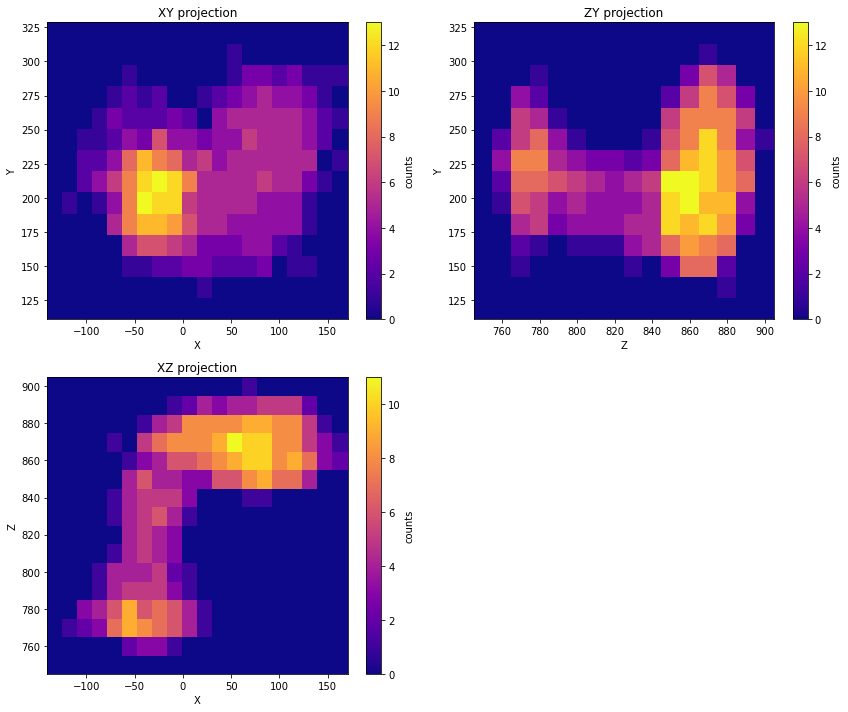

In [47]:
event_display(coors, bins);

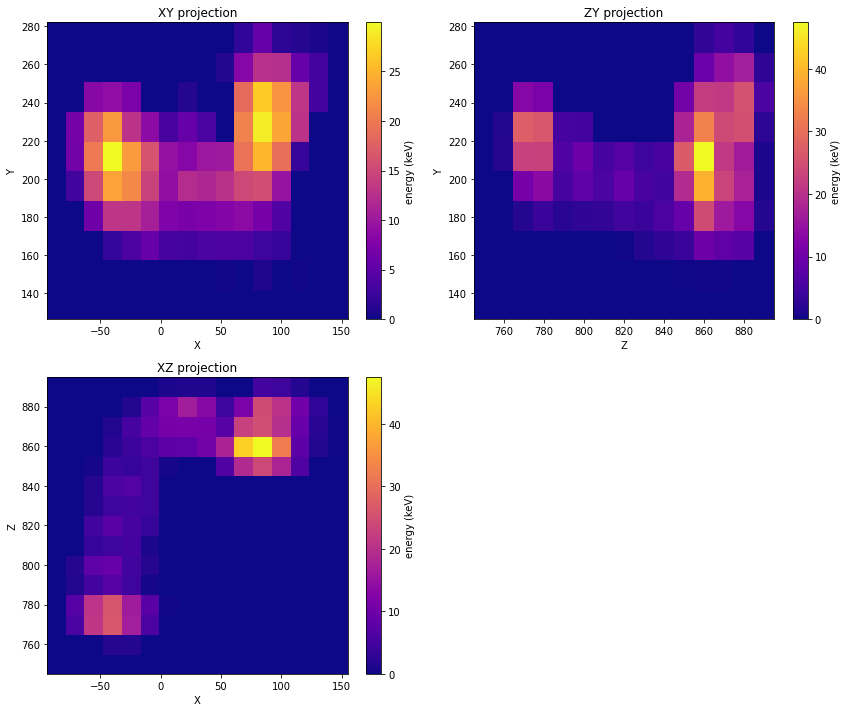

In [48]:
evtdeco  = evt[evt.decopred == 1]
enedeco  = 1e3* evtdeco.energy.values 
coorsdeco = get_coors(evtdeco)
event_display(coorsdeco, bins = bins, ene = enedeco);


In [ ]:
def display_graph(graph):
    cmap = 'plasma' # 'viridis', 'cividis', 'plasma'
    plt.figure(figsize=(6,6))

    weights = nx.get_node_attributes(G, "weight")
    node_colors = list(weights.values())
    node_sizes  = [w * 200 for w in node_colors]  # escala ajustable

    # Posiciones del grafo
    pos = nx.spring_layout(G, seed=42)

    nx.draw(graph, pos, with_labels = False, 
        node_size = node_sizes, node_color = node_colors, cmap= cmap)
    plt.colorbar(plt.cm.ScalarMappable(cmap= cmap, label="energy (keV)"))
    plt.show()


In [63]:
graph = convert_to_graph(coorsdeco, bins, enedeco)

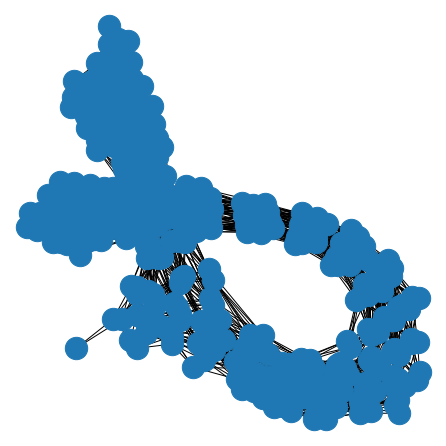

In [64]:
plt.figure(figsize=(6,6))
nx.draw(graph, node_size=500)
plt.show()

Text(0.5, 1.0, 'Event 0 XY view')

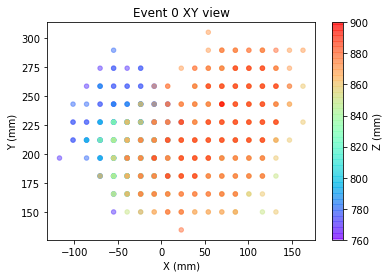

In [39]:
plt.scatter(coors[0], coors[1], c=coors[2], s=20, alpha = 0.5); plt.colorbar(label='Z (mm)'); plt.xlabel('X (mm)'); plt.ylabel('Y (mm)'); plt.title('Event 0 XY view')  

In [ ]:
def get_bins(coors, bin_widths):
    bins = [np.arange(np.min(coor) - width/2, n.max(coor) + width/2, bin_width) for coor, width in zip(coors, bin_widths)]
    return bins

def event_display(coors, bin_width):
    cv = pltext.canvas(4, 2)
    bins = get_bins(coors, bin_width)
    cv(1); plt.hist2d(coors[0], coors[1], bins = (int(200/bin_width), int(200/bin_width)), range = [[-100, 100], [-100, 100]])


[array([-117.2 , -101.65, -101.65, ...,  -70.55,  -70.55,  -70.55]),
 array([ 196.5 ,  212.05,  212.05, ..., -130.05, -114.5 ,  -98.95]),
 array([770, 770, 780, ...,  90,  90,  90])]

In [20]:
x = bin_info['min_x'].values + data['xbin'].values * bin_info['size_x'].values

In [21]:
x

array([-117.2 , -101.65, -101.65, ...,  -70.55,  -70.55,  -70.55])

In [14]:
coors = get_coors(data)

In [15]:
coors

[0         -117.2
 1            NaN
 2            NaN
 3            NaN
 4            NaN
            ...  
 6805395      NaN
 6805396      NaN
 6805397      NaN
 6805398      NaN
 6805399      NaN
 Length: 6805400, dtype: float64,
 0          196.5
 1            NaN
 2            NaN
 3            NaN
 4            NaN
            ...  
 6805395      NaN
 6805396      NaN
 6805397      NaN
 6805398      NaN
 6805399      NaN
 Length: 6805400, dtype: float64,
 0          770.0
 1            NaN
 2            NaN
 3            NaN
 4            NaN
            ...  
 6805395      NaN
 6805396      NaN
 6805397      NaN
 6805398      NaN
 6805399      NaN
 Length: 6805400, dtype: float64]

In [19]:
de = data.groupby('dataset_id')

In [36]:
de.head()

,dataset_id,binclass,xbin,ybin,zbin,energy,decolabel,decoscore,decopred
0,0,-1,24,44,77,0.000237,-1,0.087309,0
1,0,-1,25,45,77,0.000301,-1,0.076018,0
2,0,-1,25,45,78,0.000468,-1,0.084663,0
3,0,-1,25,46,77,0.000253,-1,0.067720,0
4,0,-1,25,46,78,0.000197,-1,0.069409,0
...,...,...,...,...,...,...,...,...,...
6804941,10777,-1,12,24,22,0.000193,-1,0.199058,1
6804942,10777,-1,12,25,22,0.000187,-1,0.192026,1
6804943,10777,-1,13,24,22,0.000191,-1,0.143146,1
6804944,10777,-1,14,16,22,0.000236,-1,0.090113,0


In [31]:
de_group = de.get_group(0)

In [34]:
de_group

,dataset_id,binclass,xbin,ybin,zbin,energy,decolabel,decoscore,decopred
0,0,-1,24,44,77,0.000237,-1,0.087309,0
1,0,-1,25,45,77,0.000301,-1,0.076018,0
2,0,-1,25,45,78,0.000468,-1,0.084663,0
3,0,-1,25,46,77,0.000253,-1,0.067720,0
4,0,-1,25,46,78,0.000197,-1,0.069409,0
...,...,...,...,...,...,...,...,...,...
606,0,-1,41,49,87,0.000200,-1,0.121570,1
607,0,-1,41,50,87,0.000440,-1,0.088611,0
608,0,-1,42,46,86,0.000327,-1,0.059792,0
609,0,-1,42,48,86,0.000354,-1,0.103684,0


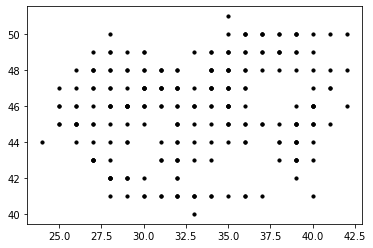

In [ ]:
sel = de_group.decopred == 1
plt.scatter(de_group[sel].xbin, de_group[sel].ybin, s=10)


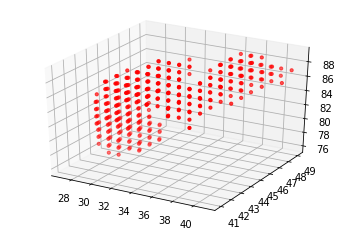

In [56]:
%matplotlib inline
#%matplotlib widget

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

x, y, z = de_group.xbin, de_group.ybin, de_group.zbin
ene = 1000.*de_group.energy
#ax.scatter(x, y, z)
ax.scatter(x[sel], y[sel], z[sel], 
              c='r', s=10)  

In [69]:
de_group.decopred

0      0
1      0
2      0
3      0
4      0
      ..
606    1
607    0
608    0
609    0
610    0
Name: decopred, Length: 611, dtype: int64

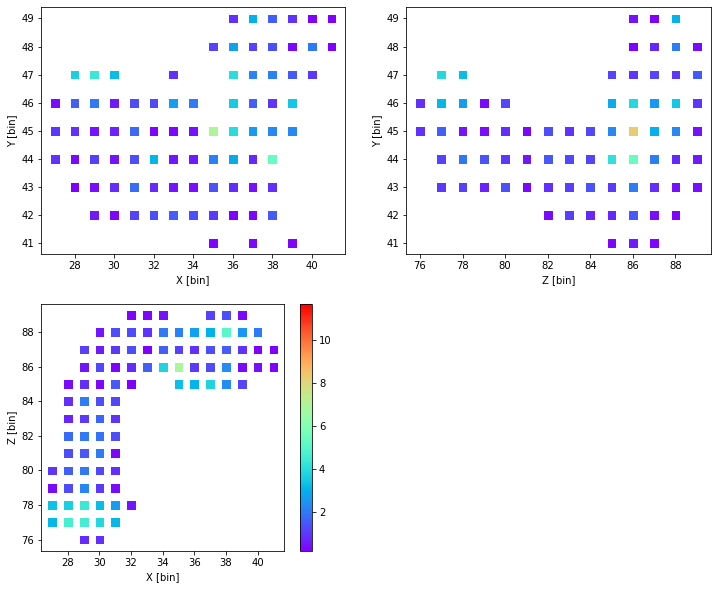

In [70]:
cv = pltext.canvas(4, 2)
sel = de_group.decopred >= 1
cv(1);
plt.scatter(x[sel], y[sel], s=60, marker = 's', c = ene[sel] ); plt.xlabel('X [bin]'); plt.ylabel('Y [bin]');
cv(2); 
plt.scatter(z[sel], y[sel], s=60, marker = 's', c = ene[sel]); plt.xlabel('Z [bin]'); plt.ylabel('Y [bin]');
cv(3);
plt.scatter(x[sel], z[sel], s=60, marker = 's', c = ene[sel]); plt.xlabel('X [bin]'); plt.ylabel('Z [bin]');
plt.colorbar();

